# 1. Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
from sklearn.neighbors import NearestNeighbors




In [2]:
sns.set(style="whitegrid")

# 2. Load the dataset

In [3]:
df = pd.read_excel("online_course_recommendation_v2 (3).xlsx")


# 3. Basic data overview

In [4]:
df.head()


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

In [6]:
df.describe()


,user_id,course_id,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,24935.663570,5006.863560,52.38354,3.959859,25052.822850,261.073369,0.746865,20.691054,4.992670
std,14406.960108,2882.085456,27.42347,0.729958,14388.188356,139.013758,0.143683,13.669148,2.237259
min,1.000000,1.000000,5.00000,1.000000,50.000000,20.000000,0.092000,1.000000,0.000000
25%,12487.750000,2523.000000,28.60000,3.500000,12583.750000,140.100000,0.649000,9.900000,3.000000
50%,24793.500000,5012.000000,52.40000,4.000000,25057.500000,262.310000,0.750000,19.920000,5.000000
75%,37382.250000,7502.000000,76.10000,4.500000,37522.000000,381.702500,0.851000,30.080000,6.000000
max,49999.000000,9999.000000,100.00000,5.000000,49999.000000,500.000000,1.000000,84.150000,19.000000


# 4. Check dataset shape

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100000
Columns: 14


# 5. Identify numerical and categorical columns

In [8]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:\n", num_cols)
print("\nCategorical Columns:\n", cat_cols)


Numerical Columns:
 Index(['user_id', 'course_id', 'course_duration_hours', 'rating',
       'enrollment_numbers', 'course_price', 'feedback_score',
       'time_spent_hours', 'previous_courses_taken'],
      dtype='object')

Categorical Columns:
 Index(['course_name', 'instructor', 'certification_offered',
       'difficulty_level', 'study_material_available'],
      dtype='object')


# 6. Missing value analysis

In [9]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
}).sort_values(by="Missing Values", ascending=False)

missing_df


,Missing Values,Percentage
user_id,0,0.0
course_id,0,0.0
course_name,0,0.0
instructor,0,0.0
course_duration_hours,0,0.0
certification_offered,0,0.0
difficulty_level,0,0.0
rating,0,0.0
enrollment_numbers,0,0.0
course_price,0,0.0


In [10]:
# 7. Duplicate rows check
df[df.duplicated(keep=False)]


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken


In [11]:
# 8. Cardinality of categorical columns
df[cat_cols].nunique().sort_values(ascending=False)


course_name                 20
instructor                  20
difficulty_level             3
certification_offered        2
study_material_available     2
dtype: int64

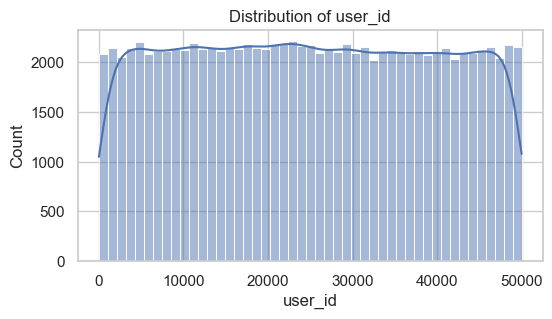

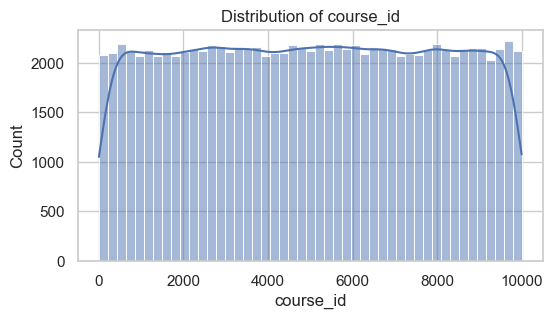

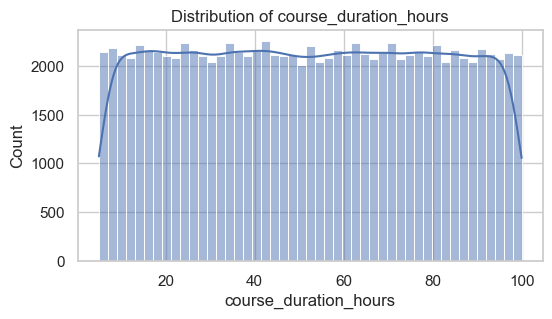

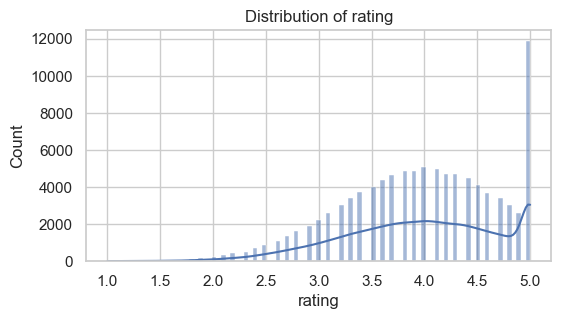

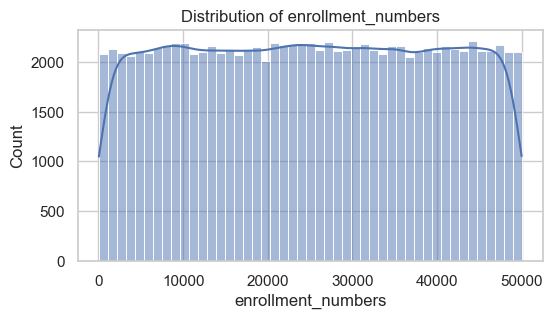

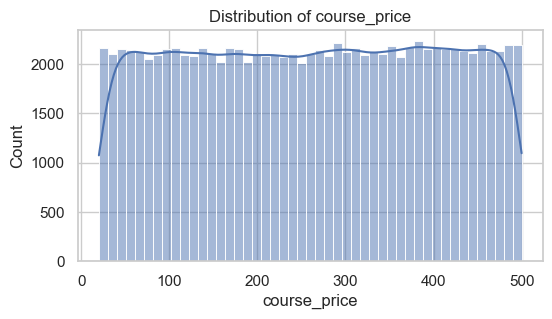

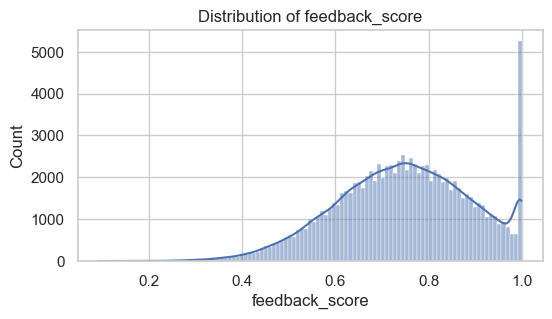

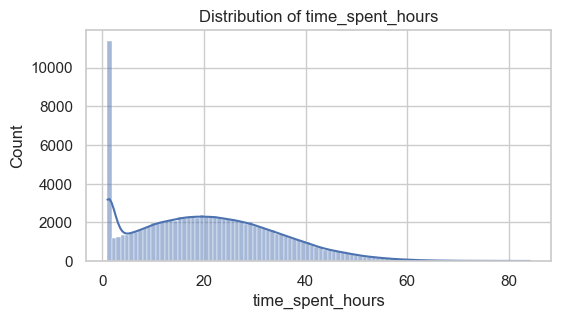

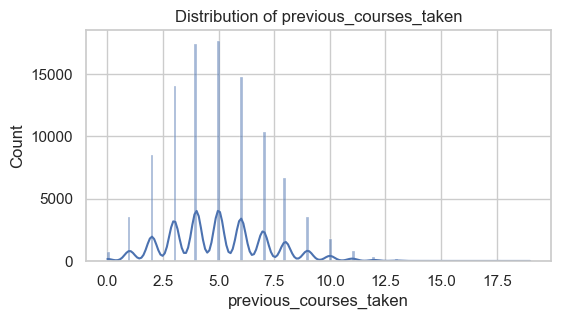

In [12]:
# 9. Distribution of numerical features
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

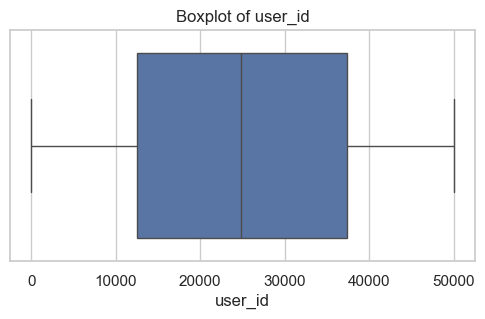

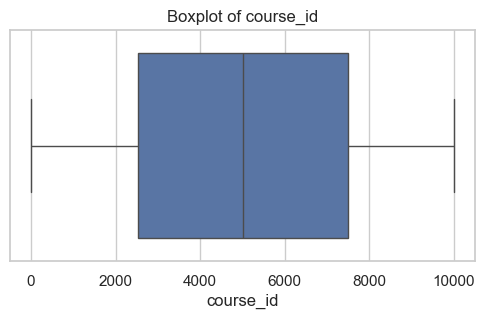

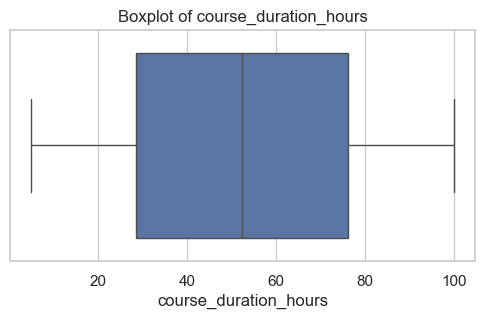

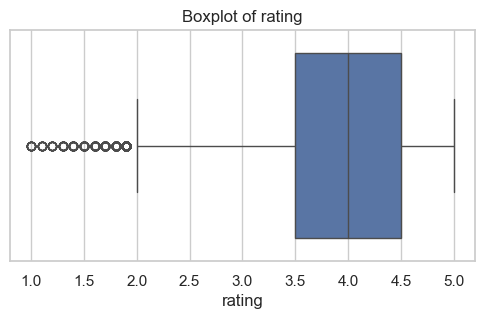

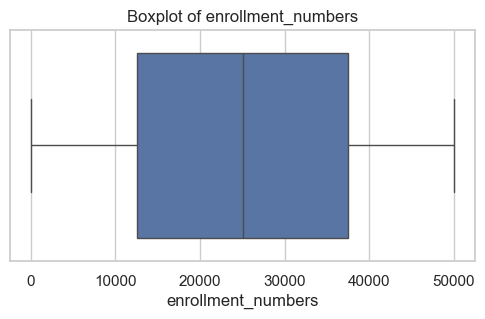

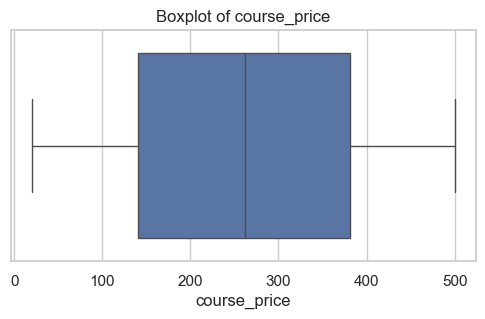

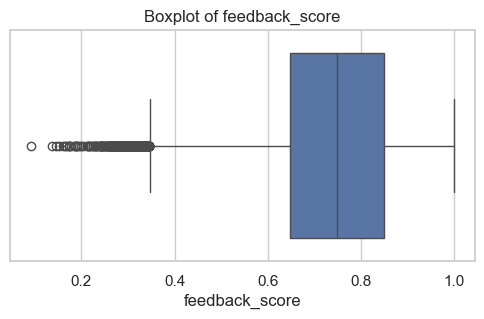

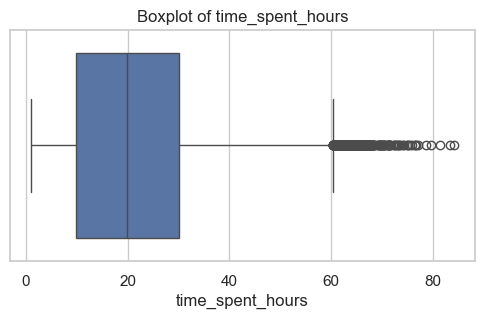

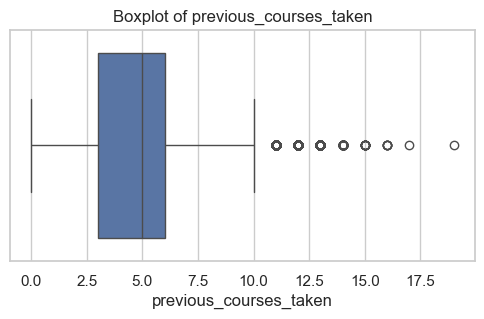

In [13]:
# 10. Boxplots for outlier detection
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


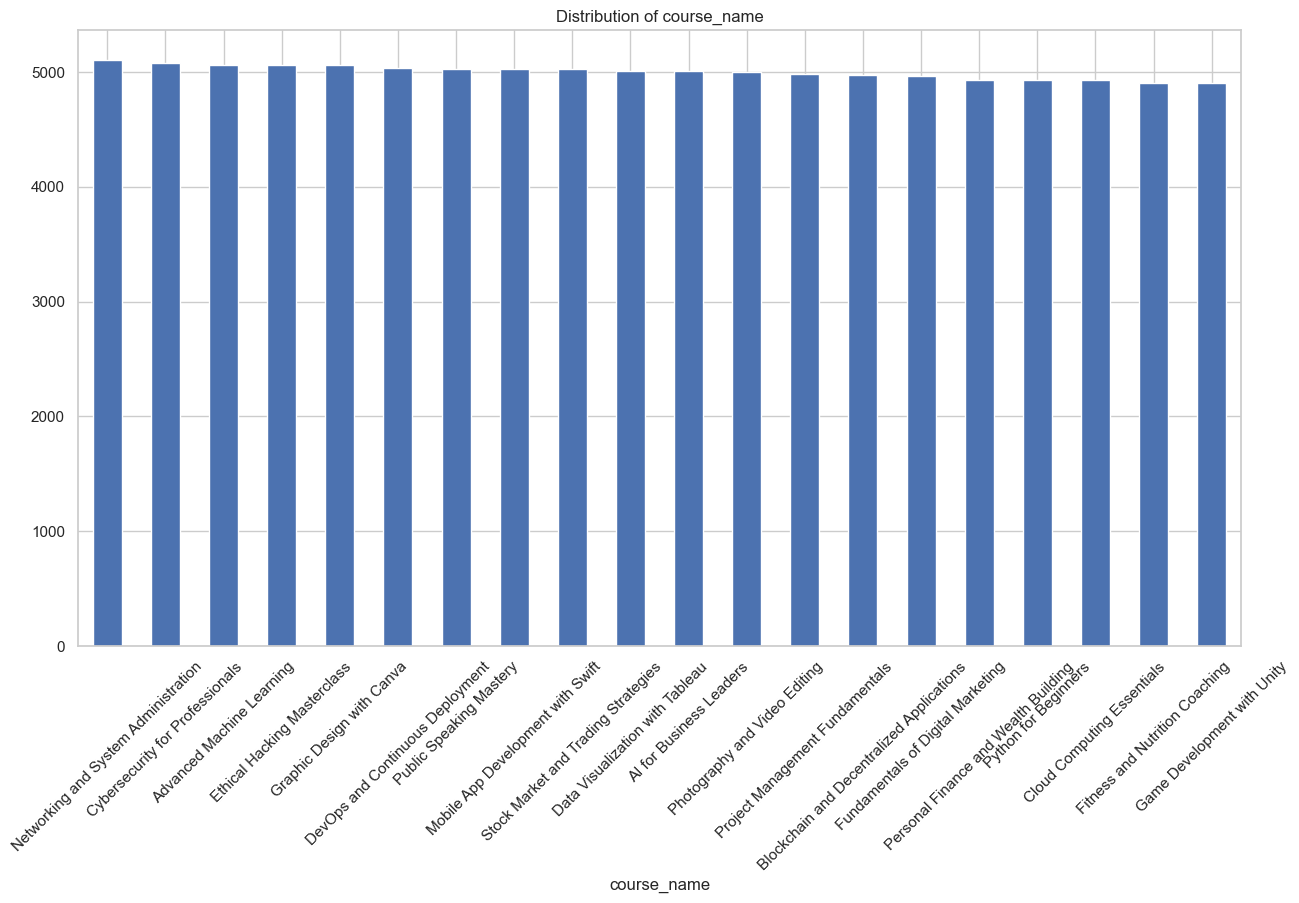

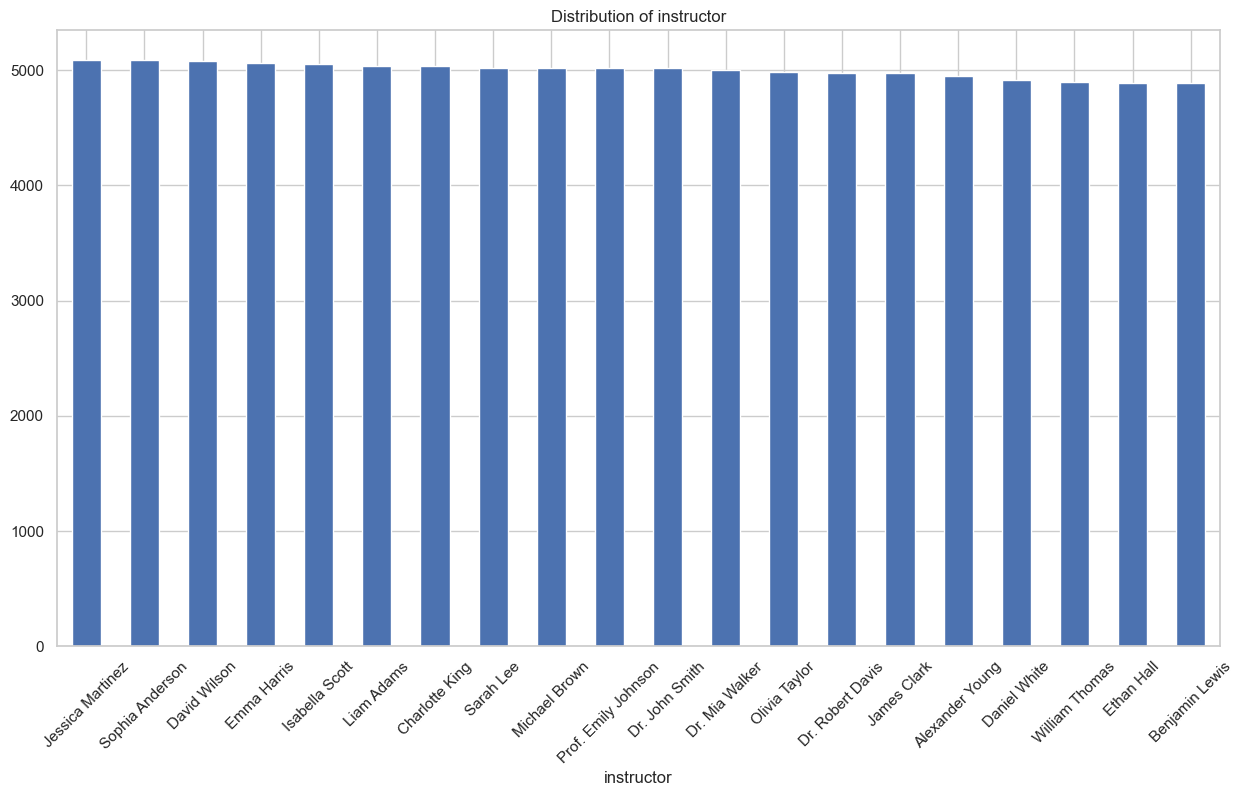

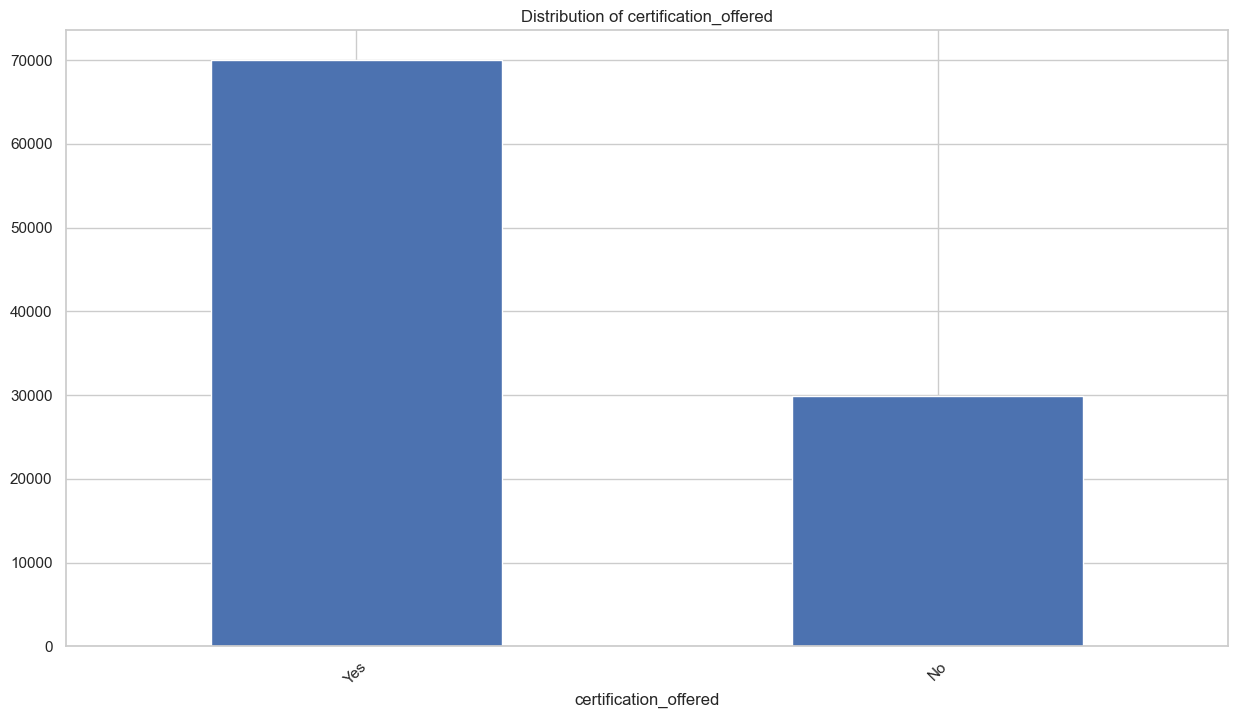

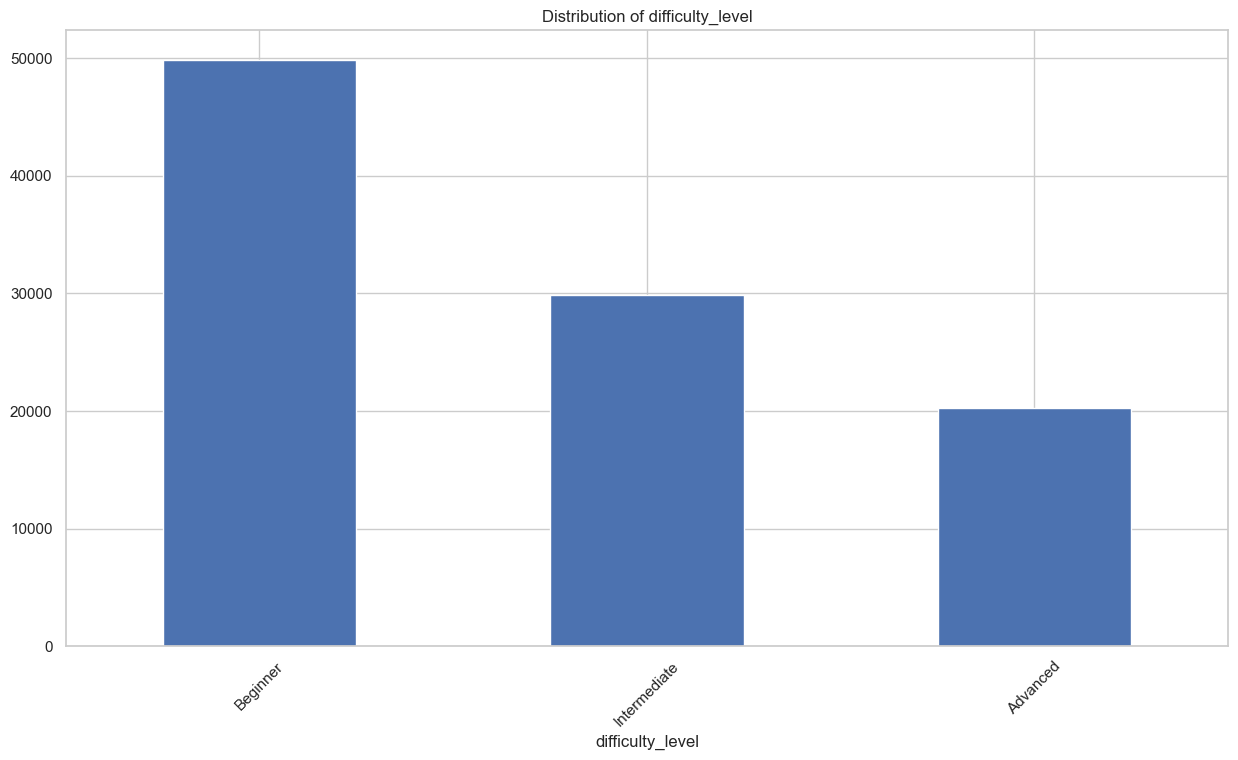

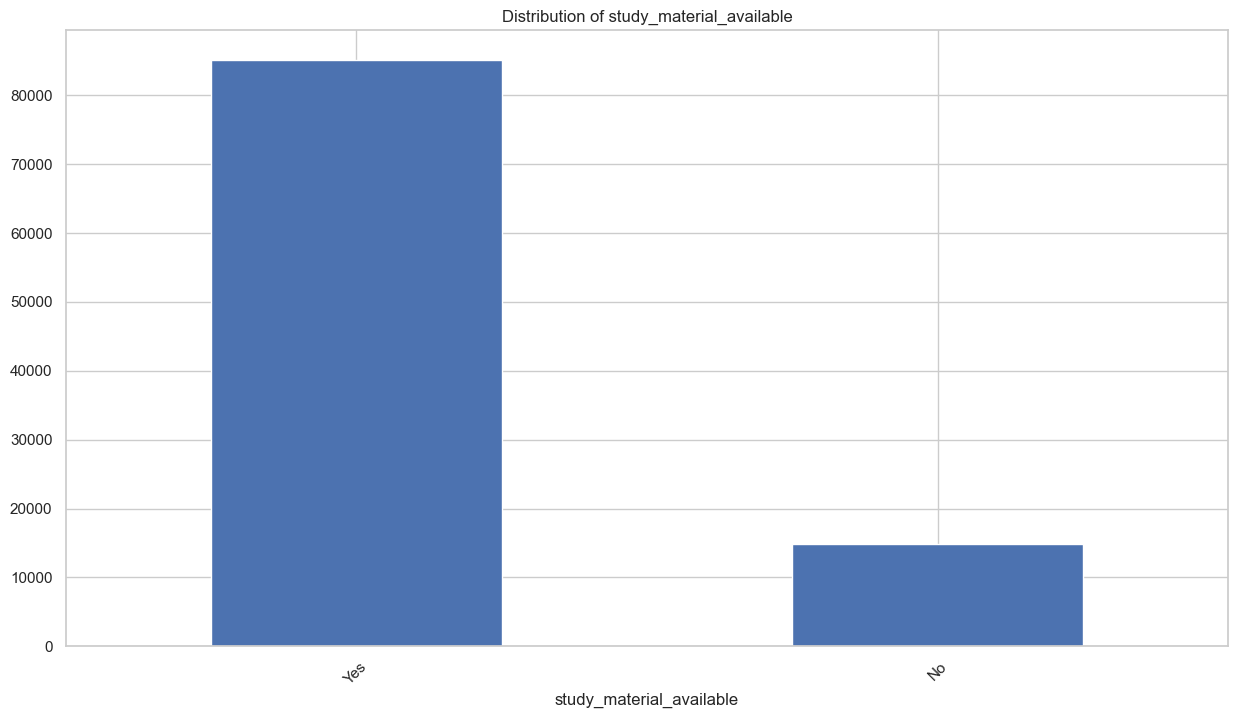

In [14]:
# 11. Categorical feature analysis
for col in cat_cols:
    plt.figure(figsize=(15,8))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

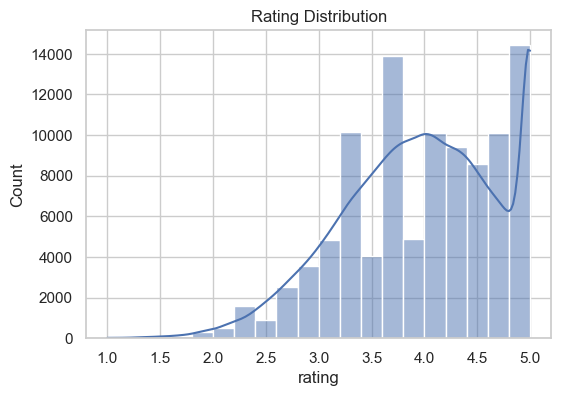

In [15]:
# 12. Rating distribution (important target variable)
plt.figure(figsize=(6,4))
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

In [16]:
# 13. Average rating by difficulty level
df.groupby("difficulty_level")["rating"].mean().sort_values(ascending=False)


difficulty_level
Intermediate    3.966213
Beginner        3.957309
Advanced        3.956754
Name: rating, dtype: float64

In [17]:
# 14. Average rating by certification availability
df.groupby("certification_offered")["rating"].mean()


certification_offered
No     3.949527
Yes    3.964274
Name: rating, dtype: float64

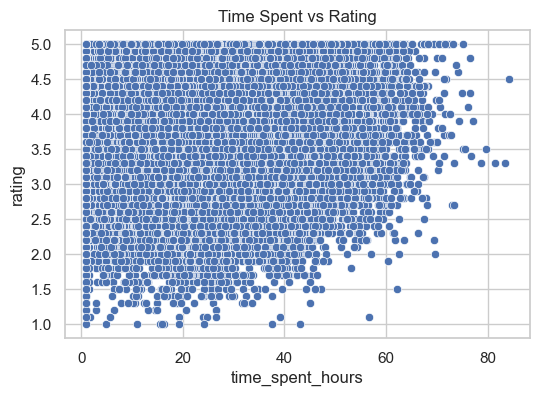

In [18]:
# 15. Engagement analysis: time spent vs rating
plt.figure(figsize=(6,4))
sns.scatterplot(x="time_spent_hours", y="rating", data=df)
plt.title("Time Spent vs Rating")
plt.show()

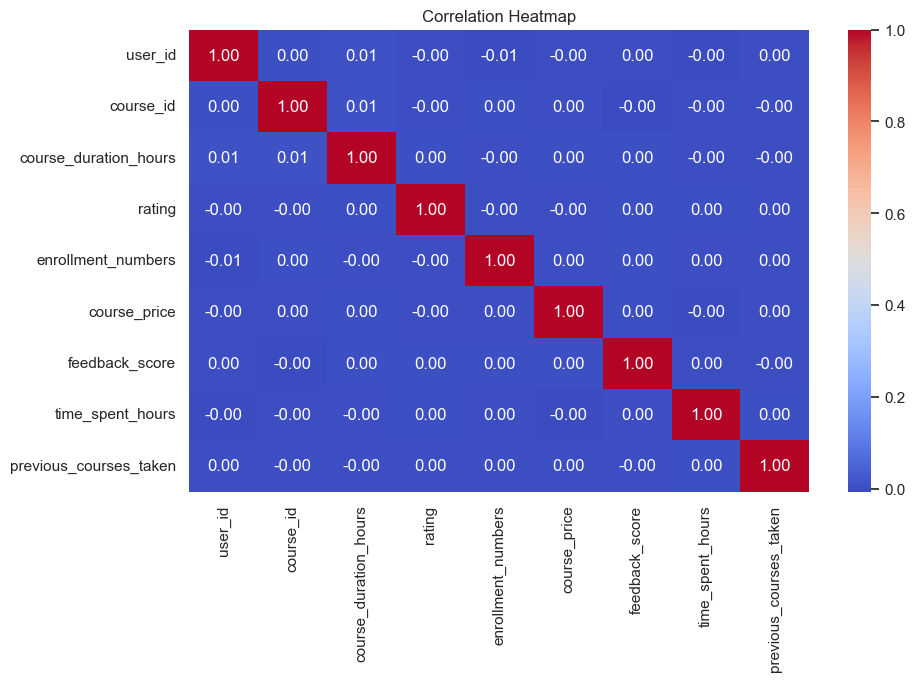

In [19]:
# 16. Correlation heatmap
plt.figure(figsize=(10,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


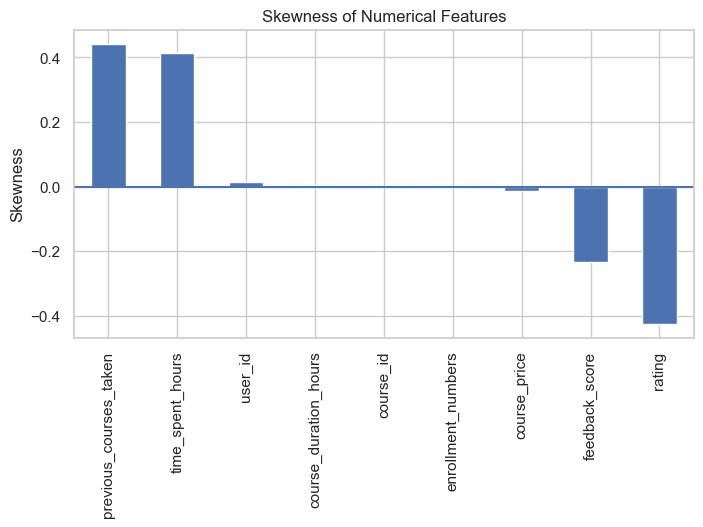

In [20]:
# 17. Skewness analysis
skew_values = df[num_cols].skew().sort_values(ascending=False)

plt.figure(figsize=(8,4))
skew_values.plot(kind="bar")
plt.title("Skewness of Numerical Features")
plt.ylabel("Skewness")
plt.axhline(0)
plt.show()


In [21]:
# 18. User-level insight
df.groupby("user_id")["course_id"].count().sort_values(ascending=False).head()  


user_id
37381    11
646      10
37998    10
26026     9
6554      9
Name: course_id, dtype: int64

In [22]:
# 19. Course popularity analysis
df.groupby("course_name")["enrollment_numbers"].mean().sort_values(ascending=False).head()


course_name
Graphic Design with Canva                    25356.299980
Fitness and Nutrition Coaching               25334.165205
Blockchain and Decentralized Applications    25313.235519
DevOps and Continuous Deployment             25241.720469
Cloud Computing Essentials                   25154.256801
Name: enrollment_numbers, dtype: float64

# Data Preprocessing

In [23]:
# Encode Yes/No columns
df["certification_offered"] = df["certification_offered"].map({"Yes": 1, "No": 0})
df["study_material_available"] = df["study_material_available"].map({"Yes": 1, "No": 0})

In [24]:
# Encode difficulty level
difficulty_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
df["difficulty_level"] = df["difficulty_level"].map(difficulty_map)

In [25]:
# Handle missing values (if any)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  int64  
 6   difficulty_level          100000 non-null  int64  
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  int64  
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

# Model Building

In [27]:

# Content-Based Filtering

content_features = [
    "course_duration_hours",
    "certification_offered",
    "difficulty_level",
    "course_price",
    "feedback_score",
    "study_material_available"
]

In [28]:

scaler = MinMaxScaler()
content_scaled = scaler.fit_transform(df[content_features])

In [29]:
tfidf = TfidfVectorizer(stop_words="english", max_features=500)
text_features = tfidf.fit_transform(df["course_name"])


In [30]:
combined_features = hstack([content_scaled, text_features]).tocsr()


In [31]:
#  KNN instead of cosine_similarity matrix
knn = NearestNeighbors(
    n_neighbors=20,   
    metric="cosine",
    algorithm="brute"
)
knn.fit(combined_features)


def content_based_recommend(course_id, top_n=5):
    idx = df[df["course_id"] == course_id].index[0]
    distances, indices = knn.kneighbors(combined_features[idx])

    # Similar courses (deduplicated)
    recs = (
        df.iloc[indices[0][1:]]
        .sort_values("rating", ascending=False)
        .drop_duplicates(subset="course_name")
    )

    # S: Fallback if not enough recommendations
    if len(recs) < top_n:
        base_course = df.iloc[idx]

        fallback = (
            df[
                (df["difficulty_level"] == base_course["difficulty_level"]) &
                (df["course_name"] != base_course["course_name"])
            ]
            .sort_values("rating", ascending=False)
            .drop_duplicates(subset="course_name")
        )

        recs = pd.concat([recs, fallback])

    return recs.head(top_n)[["course_id", "course_name", "rating"]]





In [32]:
print("\nContent-Based Recommendation:")
print(content_based_recommend(course_id=534))


Content-Based Recommendation:
       course_id                          course_name  rating
70461       4643        Photography and Video Editing     5.0
53          3773      Cybersecurity for Professionals     5.0
99991       2867  Stock Market and Trading Strategies     5.0
59           773     DevOps and Continuous Deployment     5.0
47193       1240                 Python for Beginners     5.0


In [33]:

# COLLABORATIVE FILTERING (SVD)

#  Create User–Course Matrix

user_course_matrix = df.pivot_table(
    index="user_id",
    columns="course_id",
    values="rating"
).fillna(0)

In [34]:

# Apply SVD (Collaborative Filtering)

svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(user_course_matrix)


In [35]:
def find_similar_users(user_id, top_n=3):
    user_idx = user_course_matrix.index.get_loc(user_id)
    user_vector = latent_matrix[user_idx]

    scores = latent_matrix @ user_vector
    similar_users = (
        pd.Series(scores, index=user_course_matrix.index)
        .sort_values(ascending=False)
        .iloc[1:top_n+1]   
    )

    return similar_users


In [36]:
def collaborative_recommend_explain(user_id, top_n=5):

    if user_id not in user_course_matrix.index:
        return "User not found"

    # S Similar users
    similar_users = find_similar_users(user_id, top_n=3)

    # Courses liked by similar users
    recommendations = (
        df[
            (df["user_id"].isin(similar_users.index)) &
            (df["rating"] >= 4)
        ]
        .sort_values("rating", ascending=False)
        .drop_duplicates(subset="course_name")
        .head(top_n)
    )

    return {
        "input_user": user_id,
        "similar_users": list(similar_users.index),
        "recommended_courses": recommendations[
            ["course_id", "course_name", "rating"]
        ]
    }


In [37]:
result = collaborative_recommend_explain(user_id=770)
print("\n--- Collaborative Recommendation ---")
print("Input User:", result["input_user"])
print("Similar Users:", result["similar_users"])
print("\nRecommended Courses:")
print(result["recommended_courses"])



--- Collaborative Recommendation ---
Input User: 770
Similar Users: [34056, 38600, 11545]

Recommended Courses:
       course_id                                course_name  rating
36504       1843                       Python for Beginners     5.0
52141       2670                 Cloud Computing Essentials     5.0
83380       1177  Blockchain and Decentralized Applications     5.0
69361       1639            Cybersecurity for Professionals     5.0
48207       9148                Ethical Hacking Masterclass     4.8


In [38]:

# HYBRID RECOMMENDATION


def hybrid_recommend(user_id, course_id, top_n=5):

    cb = content_based_recommend(course_id, top_n)

    cf_dict = collaborative_recommend_explain(user_id, top_n)
    cf = cf_dict["recommended_courses"]

    hybrid = (
        pd.concat([cb, cf])
        .drop_duplicates(subset="course_name")
        .head(top_n)
    )

    return hybrid[["course_id", "course_name", "rating"]]


In [39]:

print("\n--- Hybrid Recommendation ---")
print(hybrid_recommend(user_id=770, course_id=534))


--- Hybrid Recommendation ---
       course_id                          course_name  rating
70461       4643        Photography and Video Editing     5.0
53          3773      Cybersecurity for Professionals     5.0
99991       2867  Stock Market and Trading Strategies     5.0
59           773     DevOps and Continuous Deployment     5.0
47193       1240                 Python for Beginners     5.0


In [41]:
import joblib

joblib.dump(df, "df.pkl")
joblib.dump(combined_features, "combined_features.pkl")
joblib.dump(knn, "knn_model.pkl")

joblib.dump(user_course_matrix, "user_course_matrix.pkl")
joblib.dump(latent_matrix, "latent_matrix.pkl")
joblib.dump(svd, "svd_model.pkl")


['svd_model.pkl']